# Exploring CNNs Through Image Classification
 #### A summative laboratory exercise in partial fulfillment of the requirements for the course CSELEC2C: Machine Learning
 Prepared by Raul Sebastien B. Baldemoro and Jan Vincent G. Elleazar <br> Department of Computer Science, College of Information and Computing Sciences, University of Santo Tomas, City of Manila, Philippines
 <br><br>
 ***

# Overview of the Summative Laboratory Exercise
The main objective of this exercise is to familiarize ourselves with the tools used to build convolutional neural networks and applying the concepts learned in our CSELEC2C lectures into practical uses. Furthermore, the goal is **not to get the best performance** but rather to **explore how various modifications of the convolutional neural network and changes in hyperparameters affect the performance of the model.** Experiments and exploration on various aspects of the convolutional neural network are being encouraged. However, **it is important to identify the reason behind our certain decisions** in our architecture and **test it out empirically.**

For our task, we are to create convolutional neural networks for the hair types dataset. The dataset contains images with respect to different hair types. The main goal for this exercise is for us to build a convolutional neural network from scratch and to experiment on its hyperparameters.  Note that we are tasked to build your convolutional neural network on our own. **Which means that we are not allowed to use pre-trained networks and commonly defined architectures for this task.**

The documentation for this exercise is included in the same directory. 

**Prerequisites:**
- TensorFlow
- NumPy
- Pandas
- Matplotlib
- OpenCV
<br><br>
***

# Given Demonstration of the Summative Laboratory Exercise
This section presents the given demonstration of the exercise. This will be the foundation of our experimentation and exploration of the CNN architecture.
## Part 1: Checking the Dataset
**Image Checking:** Check if all files are valid

In [1]:
from pathlib import Path
import imghdr
import os

data_dir = "hair_types"
image_extensions = [".png", ".jpg"]  # add there all your images file extensions

img_type_accepted_by_tf = ["bmp", "gif", "jpeg", "png"]
for filepath in Path(data_dir).rglob("*"):
    if filepath.suffix.lower() in image_extensions:
        img_type = imghdr.what(filepath)
        if img_type is None:
            print(f"{filepath} is not an image")
            os.remove(filepath)
        elif img_type not in img_type_accepted_by_tf:
            print(f"{filepath} is a {img_type}, not accepted by TensorFlow")
            os.remove(filepath)

## Part 2: Using a DataLoader for Data Loading

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size, 
    labels='inferred',
    label_mode='categorical'
)

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 981 files belonging to 3 classes.
Using 785 files for training.
Found 981 files belonging to 3 classes.
Using 196 files for validation.


## Part 3: Visualizing the Data

2025-05-01 11:36:42.443617: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


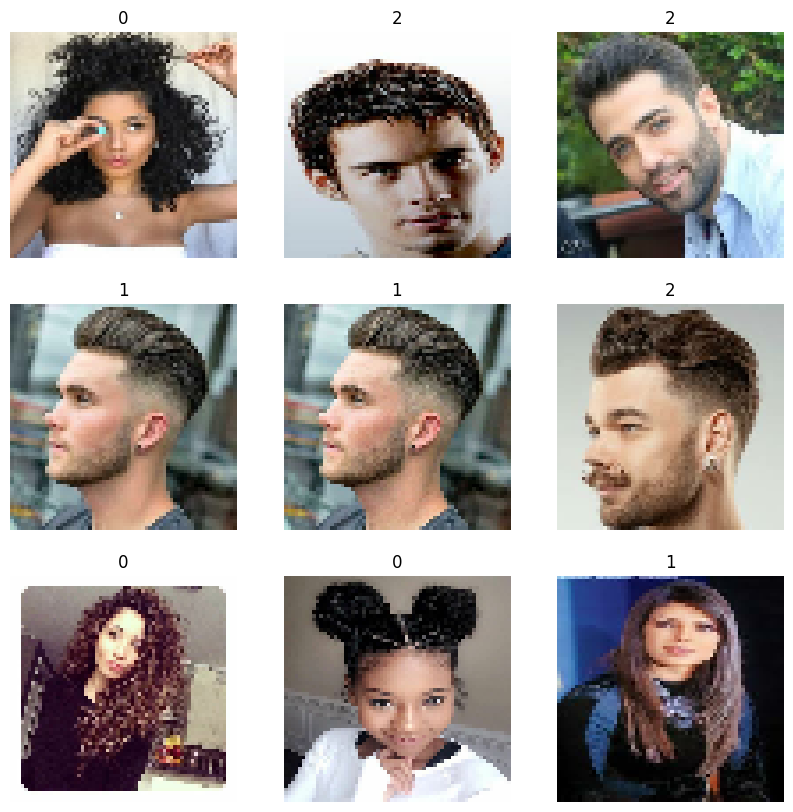

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(np.argmax(labels[i])))
        plt.axis("off")
plt.show()

## Part 4: Sample Model

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.3703 - loss: 1.0981 - val_accuracy: 0.2857 - val_loss: 1.1651
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.3886 - loss: 1.0905 - val_accuracy: 0.3827 - val_loss: 1.0801
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.4307 - loss: 1.0633 - val_accuracy: 0.4082 - val_loss: 1.0830
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.4540 - loss: 1.0530 - val_accuracy: 0.4133 - val_loss: 1.0924
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.4613 - loss: 1.0301 - val_accuracy: 0.4184 - val_loss: 1.0494
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.4838 - loss: 1.0101 - val_accuracy: 0.3980 - val_loss: 1.0576
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.4621 - loss: 0.9913 - val_accuracy: 0.4184 - val_loss: 1.0427
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.4899 - loss: 0.9875 - val_accuracy: 0.

## Part 5: Predictions for Images

In [5]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
This image is 0.88 percent curly hair, 0.11 percent straight hair, and 0.01 percent wavy hair.


***
# Experimentation and Exploration
This section presents our experiments that we conducted to learn more about the CNN architectures and hyperparamteters. Furthermore, we will test diverse combinations in modifying the architecture and fine-tuning the hyperparameters of CNN to see the how those combinations affect the performance of CNN in classifying hair types. Each experiments are listed below with its corresponding sub-experiments:
- Experiment #1: Other Preprocessing methods for Images
    - Experiment 1.1: Consistent Image Dimensions
    - Experiment 1.2: Pixel Intensity Normalization
    - Experiment 1.3: Filters and Edge Sharpening   
- Experiment #2: Implementation of Different Types of Pooling
    - Experiment 2.1: Max Pooling
    - Experiment 2.2: Average Pooling
    - Experiment 2.3: Global Max Pooling
    - Experiment 2.4: Global Average Pooling
- Experiment #3: Changing Number of Filters
    - Experiment 3.1: filters 2, 4, 8
    - Experiment 3.2: filters 4, 6, 8
    - Experiment 3.3: filters 8, 16, 32
    - Experiment 3.4: filters 16, 32, 64
    - Experiment 3.5: filters 32, 64, 128
    - Experiment 3.6: filters 16, 16, 16
- Experiment #4: Changing Kernel Size
    - Experiment 4.1: Kernel Size (3,3), (5,5), (9,9)
    - Experiment 4.2: Kernel Size (3,3), (3,3), (3,3)
    - Experiment 4.3: Kernel Size (5,5), (5,5), (5,5)
    - Experiment 4.4: Kernel Size (7,7), (5,5), (3,3)
- Experiment #5: Changing Learning Rate
    - Experiment 5.1 Learning Rate 1e-2
    - Experiment 5.2 Learning Rate 1e-4
    - Experiment 5.3 Learning Rate 1e-5

## Experiment #1: Other Preprocessing methods for Images

This experiment explores other preprocessing techniques to enhance the model's accuracy metric just from the quality of the images itself. The following sub-experiments are the other prepreocessing techniques conducted:
- Experiment 1.1: Consistent Image Dimensions
- Experiment 1.2: Pixel Intensity Normalization
- Experiment 1.3: Filters and Edge Sharpening

### Experiment 1.1: Consistent Image Dimensions
This experiment utilizes OpenCV for image resizing. The width of the images were resized into 224 pixels while maintaining the aspect ration of the images. Cropping the images was not considered due to the nature of some images where the subject (hair) is not at the center of the image.

In [ ]:
import cv2 as cv

data_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/hair_types"  # Input directory
output_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types"  # Output directory for resized images
new_width = 224

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for root, _, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        try:
            # Read the image using the full file path
            img = cv.imread(filepath)

            # Check if the image was loaded successfully
            if img is not None:
                # Resize the image
                # Get the original dimensions
                original_height, original_width = img.shape[:2]
                aspect_ratio = new_width / original_width
                new_height = int(original_height * aspect_ratio)  # Compute height based on aspect ratio
                resized_image = cv.resize(img, (new_width, new_height))

                # Construct the output file path.  Preserve directory structure.
                # Get the relative path from the original data_dir
                relative_path = os.path.relpath(filepath, data_dir)
                # Create the full output path
                output_filepath = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                output_dir_for_file = os.path.dirname(output_filepath)  # Get directory part
                if not os.path.exists(output_dir_for_file):
                    os.makedirs(output_dir_for_file)

                # Save the resized image
                cv.imwrite(output_filepath, resized_image)
                print(f"Resized and saved: {output_filepath}")

            else:
                print(f"Error loading image: {filepath}")

        except Exception as e:
            print(f"An error occurred with {filepath}: {str(e)}")

Error loading image: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/hair_types/.DS_Store
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/images282.jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/images26.jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/images32.jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/long-hairstyles-for-indian-men-6(1).jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/image3(1).jpeg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types/Wavy_Hair/images308.jpg
Resized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHIN

#### Experiment 1.1 Data Loading, Model Training, and Model Evaluation

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "resized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "resized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size, 
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.3315 - loss: 1.0987 - val_accuracy: 0.2857 - val_loss: 1.0996
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3515 - loss: 1.0984 - val_accuracy: 0.2857 - val_loss: 1.1002
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3413 - loss: 1.0982 - val_accuracy: 0.2857 - val_loss: 1.1012
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3469 - loss: 1.0986 - val_accuracy: 0.2857 - val_loss: 1.1008
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3444 - loss: 1.0943 - val_accuracy: 0.2857 - val_loss: 1.0874
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3785 - loss: 1.0798 - val_accuracy: 0.3367 - val_loss: 1.0820
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.4328 - loss: 1.0220 - val_accur

### Experiment 1.2: Pixel Intensity Normalization
This experiment utilizes NumPy to convert the image data into float32 and then divided into 255 so the pixel intensities will be scaled to the range [0.1].

In [5]:
import numpy as np

data_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/resized_hair_types"  # Input directory
output_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types"  # Output directory for normalized images

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for root, _, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        try:
            # Read the image using the full file path
            img = cv.imread(filepath)

            # Check if the image was loaded successfully
            if img is not None:
                # Convert to float32 for normalization
                img_normalized = img.astype(np.float32)

                # Normalize pixel values to the range [0, 1]
                img_normalized = img_normalized / 255.0

                # Construct the output file path.  Preserve directory structure.
                # Get the relative path from the original data_dir
                relative_path = os.path.relpath(filepath, data_dir)
                # Create the full output path
                output_filepath = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                output_dir_for_file = os.path.dirname(output_filepath)  # Get directory part
                if not os.path.exists(output_dir_for_file):
                    os.makedirs(output_dir_for_file)

                # Save the normalized image
                cv.imwrite(output_filepath, (img_normalized * 255).astype(np.uint8))  # Convert back to uint8 for saving
                print(f"Normalized and saved: {output_filepath}")

            else:
                print(f"Error loading image: {filepath}")

        except Exception as e:
            print(f"An error occurred with {filepath}: {str(e)}")

Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images282.jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images26.jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images32.jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/long-hairstyles-for-indian-men-6(1).jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/image3(1).jpeg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images308.jpg
Normalized and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types/Wavy_Hair/images320.jpg
Normalize

#### Experiment 1.2 Data Loading, Model Training, and Model Evaluation

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size, 
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.3381 - loss: 1.0987 - val_accuracy: 0.2857 - val_loss: 1.0957
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4301 - loss: 1.0846 - val_accuracy: 0.4643 - val_loss: 1.0734
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4862 - loss: 1.0472 - val_accuracy: 0.4337 - val_loss: 1.0588
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4891 - loss: 1.0133 - val_accuracy: 0.4490 - val_loss: 1.0517
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.4829 - loss: 0.9886 - val_accuracy: 0.5102 - val_loss: 1.0129
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.4740 - loss: 1.0111 - val_accuracy: 0.5357 - val_loss: 1.0055
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.5110 - loss: 0.9714 - val_accur

### Experiment 1.3: Filters and Edge Sharpening
This experiment uses Gaussian Blur and Laplacian Filter. Gaussian Blur is used for image smoothening and noise reduction while Laplacian Filter is used for edge sharpening.

In [6]:
data_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types"  # Input directory
output_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types"  # Output directory

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for root, _, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        try:
            # Read the image using the full file path
            img = cv.imread(filepath)

            # Check if the image was loaded successfully
            if img is not None:
                # Apply Gaussian Blur
                img_blurred = cv.GaussianBlur(img, (5, 5), 0)  # Kernel size 5x5, sigma = 0

                # Apply Laplacian filter
                img_laplacian = cv.Laplacian(img_blurred, cv.CV_32F)

                # Construct the output file paths.
                relative_path = os.path.relpath(filepath, data_dir)

                # Output filepath
                output_filepath = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                output_dir_for_file = os.path.dirname(output_filepath)
                if not os.path.exists(output_dir_for_file):
                    os.makedirs(output_dir_for_file)

                # Need to handle the Laplacian image differently before saving
                # 1. Find min and max
                min_val = np.min(img_laplacian)
                max_val = np.max(img_laplacian)

                # 2. Scale to 0-255
                if (max_val - min_val) != 0:
                  img_laplacian_scaled = (255 * (img_laplacian - min_val) / (max_val - min_val)).astype(np.uint8)
                else:
                   img_laplacian_scaled = np.zeros_like(img_laplacian, dtype=np.uint8)

                cv.imwrite(output_filepath, img_laplacian_scaled)

                print(f"Processed and saved: {output_filepath}")

            else:
                print(f"Error loading image: {filepath}")

        except Exception as e:
            print(f"An error occurred with {filepath}: {str(e)}")

Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images282.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images26.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images32.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/long-hairstyles-for-indian-men-6(1).jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/image3(1).jpeg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images308.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/filtered_hair_types/Wavy_Hair/images320.jpg
Processed and saved: /Users/jj

#### Experiment 1.3 Data Loading, Model Training, and Model Evaluation

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "filtered_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "filtered_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size, 
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.3631 - loss: 1.0990 - val_accuracy: 0.2857 - val_loss: 1.1007
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3515 - loss: 1.0982 - val_accuracy: 0.2857 - val_loss: 1.1011
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3413 - loss: 1.0986 - val_accuracy: 0.2857 - val_loss: 1.1023
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.3469 - loss: 1.0985 - val_accuracy: 0.2857 - val_loss: 1.1024
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3444 - loss: 1.0987 - val_accuracy: 0.2857 - val_loss: 1.1028
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3581 - loss: 1.0977 - val_accuracy: 0.2857 - val_loss: 1.1037
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3701 - loss: 1.0963 - val_accur

## Experiment #2: Implementation of Different Types of Pooling

This experiment explores the implementation of different types of pooling. The normalized hair types dataset will be used for this experiment since the sample model performed better in the said dataset. The following sub-experiments are the implementation of different types of pooling. 
- Experiment 2.1: Max Pooling
- Experiment 2.2: Average Pooling
- Experiment 2.3: Global Max Pooling
- Experiment 2.4: Global Average Pooling

### Experiment 2.1: Max Pooling
This experiment uses MaxPooling2D in Keras. A Max Pooling layer was added on each Conv2D layer.

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2))) # Added Max Pooling

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2))) # Added Max Pooling

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2,2))) # Added Max Pooling

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_with_pooling.png', show_shapes=True) #Changed filename
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.3714 - loss: 1.0964 - val_accuracy: 0.4235 - val_loss: 1.0835
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.4253 - loss: 1.0584 - val_accuracy: 0.4337 - val_loss: 1.0491
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4996 - loss: 1.0056 - val_accuracy: 0.4439 - val_loss: 1.0361
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4637 - loss: 0.9959 - val_accuracy: 0.4439 - val_loss: 0.9955
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.5186 - loss: 0.9245 - val_accuracy: 0.4184 - val_loss: 1.0445
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.4992 - loss: 0.9605 - val_accuracy: 0.4796 - val_loss: 0.9826
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5294 - loss: 0.9139 - val_accur

### Experiment 2.2: Average Pooling
This experiment uses AveragePooling2D in Keras. An Average Pooling layer was added on each Conv2D layer.

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) # Added Average Pooling

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) # Added Average Pooling

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) # Added Average Pooling

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_with_average_pooling.png', show_shapes=True) #Changed filename
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.3709 - loss: 1.0980 - val_accuracy: 0.4286 - val_loss: 1.0839
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4619 - loss: 1.0657 - val_accuracy: 0.4133 - val_loss: 1.0868
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.4603 - loss: 1.0275 - val_accuracy: 0.4184 - val_loss: 1.0549
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4858 - loss: 0.9751 - val_accuracy: 0.4490 - val_loss: 1.0030
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5211 - loss: 0.9293 - val_accuracy: 0.4796 - val_loss: 0.9992
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4916 - loss: 0.9567 - val_accuracy: 0.4796 - val_loss: 0.9989
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5320 - loss: 0.9316 - val_accur

### Experiment 2.3: Global Max Pooling
This experiment uses GlobalMaxPooling2D in Keras. A Global Max Pooling layer was added after the last Conv2D layer.

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalMaxPooling2D()) # Replaced with Global Max Pooling
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_with_global_max_pooling.png', show_shapes=True) #Changed filename
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.3115 - loss: 1.1021 - val_accuracy: 0.2857 - val_loss: 1.0979
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.3571 - loss: 1.0946 - val_accuracy: 0.2857 - val_loss: 1.0963
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.3624 - loss: 1.0786 - val_accuracy: 0.4490 - val_loss: 1.0681
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.4712 - loss: 1.0485 - val_accuracy: 0.4592 - val_loss: 1.0462
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.4802 - loss: 1.0320 - val_accuracy: 0.5153 - val_loss: 1.0412
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.5005 - loss: 1.0221 - val_accuracy: 0.5510 - val_loss: 1.0087
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.5088 - loss: 0.9839 - val_accu

### Experiment 2.4: Global Max Pooling
This experiment uses GlobalAveragePooling2D in Keras. A Global Average Pooling layer was added after the last Conv2D layer.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D()) # Retained Global Average Pooling
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_with_global_average_pooling.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.3647 - loss: 1.0984 - val_accuracy: 0.4643 - val_loss: 1.0854
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4561 - loss: 1.0698 - val_accuracy: 0.4388 - val_loss: 1.0668
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.4901 - loss: 1.0215 - val_accuracy: 0.4184 - val_loss: 1.0833
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4757 - loss: 1.0243 - val_accuracy: 0.4796 - val_loss: 1.0186
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4958 - loss: 0.9780 - val_accuracy: 0.4541 - val_loss: 1.0162
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.4428 - loss: 1.0133 - val_accuracy: 0.4796 - val_loss: 1.0075
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5052 - loss: 0.9610 - val_accur

## Experiment #3: Changing Number of Filters

This experiment explores the effects of different number of filters. The normalized hair types dataset will be used for this experiment and Average Pooling will be used since it has the highest accuracy while maintaining its generalization. The following sub-experiments are the implementation of different number of filters. 
- Experiment 3.1: filters 2, 4, 8
- Experiment 3.2: filters 4, 6, 8
- Experiment 3.3: filters 8, 16, 32
- Experiment 3.4: filters 16, 32, 64
- Experiment 3.5: filters 32, 64, 128
- Experiment 3.6: filters 16, 16, 16

#### Experiment 3.1: filters 2, 4, 8
This experiment uses 2, 4, and 8 as the number of filters.

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=2, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=4, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=8, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter248.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.3351 - loss: 1.0974 - val_accuracy: 0.3571 - val_loss: 1.0848
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4117 - loss: 1.0818 - val_accuracy: 0.4337 - val_loss: 1.0592
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4748 - loss: 1.0379 - val_accuracy: 0.4490 - val_loss: 1.0124
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4947 - loss: 0.9788 - val_accuracy: 0.4694 - val_loss: 0.9818
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5419 - loss: 0.9322 - val_accuracy: 0.4286 - val_loss: 1.0298
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4685 - loss: 0.9803 - val_accuracy: 0.5408 - val_loss: 0.9914
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.5404 - loss: 0.9215 - val_accur

#### Experiment 3.2: filters 4, 6, 8
This experiment uses 4, 6, and 8 as the number of filters.

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=6, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=8, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter468.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.3631 - loss: 1.0985 - val_accuracy: 0.2857 - val_loss: 1.0975
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.3809 - loss: 1.0848 - val_accuracy: 0.4439 - val_loss: 1.0843
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4522 - loss: 1.0457 - val_accuracy: 0.4082 - val_loss: 1.0679
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4946 - loss: 1.0259 - val_accuracy: 0.4388 - val_loss: 1.0418
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.5038 - loss: 0.9613 - val_accuracy: 0.4541 - val_loss: 1.0292
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.5057 - loss: 0.9681 - val_accuracy: 0.4796 - val_loss: 1.0154
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.5305 - loss: 0.9262 - val_accur

#### Experiment 3.3: filters 8, 16, 32
This experiment uses 8, 16, and 32 as the number of filters.

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=8, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=32, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter81632.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.3608 - loss: 1.0994 - val_accuracy: 0.3316 - val_loss: 1.0831
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.4284 - loss: 1.0752 - val_accuracy: 0.4082 - val_loss: 1.0645
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4938 - loss: 1.0154 - val_accuracy: 0.3878 - val_loss: 1.0349
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.5027 - loss: 0.9830 - val_accuracy: 0.4490 - val_loss: 1.0312
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5205 - loss: 0.9429 - val_accuracy: 0.4541 - val_loss: 1.0356
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4965 - loss: 0.9656 - val_accuracy: 0.4643 - val_loss: 1.0114
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.5081 - loss: 0.9253 - val_accur

#### Experiment 3.4: filters 16, 32, 64
This experiment uses 16, 32, and 64 as the number of filters.

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=32, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=64, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter163264.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.3682 - loss: 1.1010 - val_accuracy: 0.3469 - val_loss: 1.0819
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4736 - loss: 1.0443 - val_accuracy: 0.3367 - val_loss: 1.1628
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.4447 - loss: 1.0221 - val_accuracy: 0.4592 - val_loss: 1.0326
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5397 - loss: 0.9696 - val_accuracy: 0.5153 - val_loss: 0.9678
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.5414 - loss: 0.9051 - val_accuracy: 0.5051 - val_loss: 0.9914
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.5175 - loss: 0.9306 - val_accuracy: 0.4643 - val_loss: 0.9943
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.5410 - loss: 0.9141 - val_accu

#### Experiment 3.5: filters 32, 64, 128
This experiment uses 32, 64, and 128 as the number of filters.

In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=32, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=64, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=128, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter3264128.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.3360 - loss: 1.1131 - val_accuracy: 0.2857 - val_loss: 1.0796
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.4003 - loss: 1.0591 - val_accuracy: 0.4694 - val_loss: 1.0635
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 234ms/step - accuracy: 0.4893 - loss: 1.0155 - val_accuracy: 0.4694 - val_loss: 1.0469
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.4666 - loss: 1.0162 - val_accuracy: 0.4694 - val_loss: 1.0072
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.5017 - loss: 0.9450 - val_accuracy: 0.4694 - val_loss: 0.9829
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.4684 - loss: 0.9536 - val_accuracy: 0.5153 - val_loss: 0.9871
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.5466 - loss: 0.9209 - va

#### Experiment 3.6: filters 16, 16, 16
This experiment uses 16 as the number of filters.

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_filter161616.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.3549 - loss: 1.1012 - val_accuracy: 0.3214 - val_loss: 1.0920
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.4149 - loss: 1.0864 - val_accuracy: 0.3622 - val_loss: 1.0982
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.4415 - loss: 1.0751 - val_accuracy: 0.4031 - val_loss: 1.0685
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.4926 - loss: 0.9944 - val_accuracy: 0.4235 - val_loss: 1.0378
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4978 - loss: 0.9696 - val_accuracy: 0.4388 - val_loss: 1.0514
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4661 - loss: 0.9895 - val_accuracy: 0.4949 - val_loss: 1.0107
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5489 - loss: 0.9446 - val_accur

## Experiment #4: Changing Kernel Size

This experiment explores the effects of different kernel sizes. The normalized hair types dataset will be used for this experiment, Average Pooling will be used, and 16 as the number of all filters since it achieved better generalization compared to other number of filters. The following sub-experiments are the implementation of different kernel sizes.
- Experiment 4.1: Kernel Size (3,3), (5,5), (9,9)
- Experiment 4.2: Kernel Size (3,3), (3,3), (3,3)
- Experiment 4.3: Kernel Size (5,5), (5,5), (5,5)
- Experiment 4.4: Kernel Size (7,7), (5,5), (3,3)

#### Experiment 4.1: Kernel Size (3,3), (5,5), (9,9)
This experiment uses (3,3), (5,5), (9,9) as the kernel size.

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(9,9), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_kernel359.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3631 - loss: 1.0967 - val_accuracy: 0.4337 - val_loss: 1.0784
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4728 - loss: 1.0587 - val_accuracy: 0.3980 - val_loss: 1.0806
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5133 - loss: 1.0015 - val_accuracy: 0.4184 - val_loss: 1.0401
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5357 - loss: 0.9674 - val_accuracy: 0.5153 - val_loss: 0.9995
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5846 - loss: 0.9247 - val_accuracy: 0.4592 - val_loss: 1.0139
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5437 - loss: 0.9209 - val_accuracy: 0.4949 - val_loss: 0.9722
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6150 - loss: 0.8751 - val_accur

#### Experiment 4.1: Kernel Size (3,3), (3,3), (3,3)
This experiment uses (3,3) as the kernel size of all Conv2D layers.

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_kernel333.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3437 - loss: 1.0985 - val_accuracy: 0.3878 - val_loss: 1.0965
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.4009 - loss: 1.0952 - val_accuracy: 0.4235 - val_loss: 1.0893
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4488 - loss: 1.0846 - val_accuracy: 0.4235 - val_loss: 1.0738
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4423 - loss: 1.0640 - val_accuracy: 0.3878 - val_loss: 1.0860
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4380 - loss: 1.0412 - val_accuracy: 0.4745 - val_loss: 1.0459
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4698 - loss: 1.0423 - val_accuracy: 0.5000 - val_loss: 1.0298
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5259 - loss: 1.0121 - val_accur

#### Experiment 4.3: Kernel Size (5,5), (5,5), (5,5)
This experiment uses (5,5) as the kernel size of all Conv2D layers.

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_kernel555.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3811 - loss: 1.0991 - val_accuracy: 0.3622 - val_loss: 1.0840
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4273 - loss: 1.0815 - val_accuracy: 0.4439 - val_loss: 1.0749
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4638 - loss: 1.0605 - val_accuracy: 0.4286 - val_loss: 1.0615
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5196 - loss: 1.0061 - val_accuracy: 0.4439 - val_loss: 1.0066
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5369 - loss: 0.9613 - val_accuracy: 0.4592 - val_loss: 1.0348
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4841 - loss: 1.0070 - val_accuracy: 0.4745 - val_loss: 0.9952
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5418 - loss: 0.9372 - val_accur

#### Experiment 4.4: Kernel Size (7,7), (5,5), (3,3)
This experiment uses (7,7), (5,5) and (3,3) as the kernel size.

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(7,7), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_kernel753.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3419 - loss: 1.1020 - val_accuracy: 0.3010 - val_loss: 1.0979
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4277 - loss: 1.0933 - val_accuracy: 0.3316 - val_loss: 1.0923
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4343 - loss: 1.0649 - val_accuracy: 0.4439 - val_loss: 1.0350
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4793 - loss: 1.0117 - val_accuracy: 0.4388 - val_loss: 1.0111
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5086 - loss: 0.9679 - val_accuracy: 0.4592 - val_loss: 1.0428
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4724 - loss: 1.0116 - val_accuracy: 0.4745 - val_loss: 1.0141
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5345 - loss: 0.9533 - val_accur

## Experiment #5: Changing Learning Rate

This experiment explores the effects of different learning rate. The normalized hair types dataset will be used for this experiment, Average Pooling will be used,16 as the number of all filters, and (3,3) as the kernel size in all Conv2D layers since it achieved better generalization than other kernel size. The following sub-experiments are the implementation of different learning rate.
- Experiment 5.1 Learning Rate 1e-2
- Experiment 5.2 Learning Rate 1e-4
- Experiment 5.3 Learning Rate 1e-5

#### Experiment 5.1: Learning Rate 1e-2
This experiment uses 1e-2 as the learning rate.

In [36]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_lr1e2.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-2),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.3366 - loss: 1.1071 - val_accuracy: 0.2857 - val_loss: 1.1030
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3534 - loss: 1.0996 - val_accuracy: 0.3724 - val_loss: 1.1006
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3713 - loss: 1.0974 - val_accuracy: 0.2857 - val_loss: 1.1055
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3469 - loss: 1.0995 - val_accuracy: 0.2857 - val_loss: 1.1014
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3444 - loss: 1.0994 - val_accuracy: 0.2857 - val_loss: 1.1039
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3581 - loss: 1.0982 - val_accuracy: 0.2857 - val_loss: 1.1043
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3701 - loss: 1.0966 - val_accur

#### Experiment 5.2: Learning Rate 1e-4
This experiment uses 1e-4 as the learning rate.

In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_lr1e4.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3217 - loss: 1.0984 - val_accuracy: 0.3827 - val_loss: 1.0979
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3304 - loss: 1.0980 - val_accuracy: 0.3776 - val_loss: 1.0976
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3487 - loss: 1.0979 - val_accuracy: 0.4235 - val_loss: 1.0976
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3926 - loss: 1.0973 - val_accuracy: 0.4184 - val_loss: 1.0973
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3884 - loss: 1.0969 - val_accuracy: 0.4439 - val_loss: 1.0971
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4366 - loss: 1.0962 - val_accuracy: 0.3980 - val_loss: 1.0971
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4408 - loss: 1.0956 - val_accur

#### Experiment 5.3: Learning Rate 1e-5
This experiment uses 1e-5 as the learning rate.

In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test_lr1e5.png', show_shapes=True) 
epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)


Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3209 - loss: 1.0993 - val_accuracy: 0.3418 - val_loss: 1.0971
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3264 - loss: 1.0989 - val_accuracy: 0.3418 - val_loss: 1.0969
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3108 - loss: 1.1003 - val_accuracy: 0.3418 - val_loss: 1.0968
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3418 - loss: 1.0977 - val_accuracy: 0.3418 - val_loss: 1.0967
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3425 - loss: 1.0971 - val_accuracy: 0.3418 - val_loss: 1.0967
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3440 - loss: 1.0967 - val_accuracy: 0.3418 - val_loss: 1.0967
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3108 - loss: 1.0997 - val_accur

***
## Predicting the Image with the Best Model
In this section, the best model will be used based from the previous experiments to predict the image. The normalized hair types dataset will be used, Average Pooling will be used, 16 as the number of all filters, (3,3) as the kernel size in all Conv2D layers, and le-2 as the learning rate will be used.

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "normalized_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3631 - loss: 1.0984 - val_accuracy: 0.2857 - val_loss: 1.0987
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3516 - loss: 1.0952 - val_accuracy: 0.3061 - val_loss: 1.0944
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3672 - loss: 1.0853 - val_accuracy: 0.3724 - val_loss: 1.0770
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4758 - loss: 1.0544 - val_accuracy: 0.4235 - val_loss: 1.0308
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5031 - loss: 1.0000 - val_accuracy: 0.4388 - val_loss: 1.0447
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4527 - loss: 1.0362 - val_accuracy: 0.4796 - val_loss: 1.0095
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5273 - loss: 0.9901 - val_accur

***
## Other Experiment
Out of curiosity, this experiment utilizes the Gaussian Blur hair types dataset, as oppose to earlier with the mixture of Laplacian Filter, in order to determine if this filter would make the model perform better.

In [39]:
data_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/normalized_hair_types"  # Input directory
output_dir = "/Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types"  # Output directory

# Create the output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for root, _, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        try:
            # Read the image using the full file path
            img = cv.imread(filepath)

            # Check if the image was loaded successfully
            if img is not None:
                # Apply Gaussian Blur
                img_blurred = cv.GaussianBlur(img, (5, 5), 0)  # Kernel size 5x5, sigma = 0

                # Construct the output file paths.
                relative_path = os.path.relpath(filepath, data_dir)

                # Output filepath
                output_filepath = os.path.join(output_dir, relative_path)

                # Ensure the output directory exists
                output_dir_for_file = os.path.dirname(output_filepath)
                if not os.path.exists(output_dir_for_file):
                    os.makedirs(output_dir_for_file)

                cv.imwrite(output_filepath, img_blurred)

                print(f"Processed and saved: {output_filepath}")

            else:
                print(f"Error loading image: {filepath}")

        except Exception as e:
            print(f"An error occurred with {filepath}: {str(e)}")

Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images282.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images26.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images32.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/long-hairstyles-for-indian-men-6(1).jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/image3(1).jpeg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images308.jpg
Processed and saved: /Users/jjelleazarr/Documents/VS Code Projects/MACHINE LEARNING/LABEX3/gaussianblur_hair_types/Wavy_Hair/images320.jpg
Pr

#### Using the same best model from earlier to predict the image.

In [40]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "gaussianblur_hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "gaussianblur_hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))
model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2))) 

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

Found 980 files belonging to 3 classes.
Using 784 files for training.
Found 980 files belonging to 3 classes.
Using 196 files for validation.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3631 - loss: 1.0998 - val_accuracy: 0.2857 - val_loss: 1.1005
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3515 - loss: 1.0981 - val_accuracy: 0.2857 - val_loss: 1.0994
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3413 - loss: 1.0969 - val_accuracy: 0.2857 - val_loss: 1.0979
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3497 - loss: 1.0938 - val_accuracy: 0.3061 - val_loss: 1.0947
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3997 - loss: 1.0852 - val_accuracy: 0.4643 - val_loss: 1.0681
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4246 - loss: 1.0693 - val_accuracy: 0.4388 - val_loss: 1.0520
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4577 - loss: 1.0465 - val_accur

***
# Results, Analysis, and Conclusion
Please refer to our written report for the discussion of the findings of this laboratory exercise. Thank you :)